# Alicorp - Caso Práctico Machine Learning Engineer
## 01 - Análisis Exploratorio de Datos (EDA) y Preprocesamiento

**Objetivo:** Explorar los datos de clientes y transaccionales, realizar limpieza, imputación de nulos y generar variables RFM para crear el ABT (Analytical Base Table) final que se utilizará para el modelado.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")




### 1. Carga de Datos




In [2]:
# Definir rutas
RAW_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'

# Crear carpeta de procesados si no existe
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Cargar datasets
try:
    df_cliente = pd.read_csv(os.path.join(RAW_DIR, 'data_cliente.csv'))
    df_transaccional = pd.read_csv(os.path.join(RAW_DIR, 'data_transaccional.csv'))
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print("Error: No se encontraron los archivos en la carpeta data/raw/. Por favor, asegúrate de colocar data_cliente.csv y data_transaccional.csv allí.")
    # Stop execution if data is missing
    raise




Datos cargados exitosamente.


### 2. Análisis Exploratorio: Datos Cliente




In [3]:
print(f"Dimensiones Datos Cliente: {df_cliente.shape}")
df_cliente.head()




Dimensiones Datos Cliente: (5254, 8)


,customer_id,territory_id,segment,age_alicorp,has_credit_line,has_perfect_customer,has_marketing_impulse,target
0,1,T1,S3,9.0,1,0,1,1
1,2,T2,S3,0.0,0,1,1,0
2,3,T1,S3,4.0,1,0,0,0
3,4,T1,S3,2.0,0,1,0,0
4,5,T1,S3,2.0,0,1,1,0


In [4]:
# Información general y nulos
df_cliente.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5254 entries, 0 to 5253
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            5254 non-null   int64  
 1   territory_id           5254 non-null   object 
 2   segment                5254 non-null   object 
 3   age_alicorp            5179 non-null   float64
 4   has_credit_line        5254 non-null   int64  
 5   has_perfect_customer   5254 non-null   int64  
 6   has_marketing_impulse  5254 non-null   int64  
 7   target                 5254 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 328.5+ KB


In [5]:
# Resumen de variables numéricas
df_cliente.describe()




,customer_id,age_alicorp,has_credit_line,has_perfect_customer,has_marketing_impulse,target
count,5254.000000,5179.000000,5254.000000,5254.000000,5254.000000,5254.000000
mean,2627.500000,5.044410,0.503807,0.332889,0.338980,0.162733
std,1516.843488,3.145493,0.500033,0.471292,0.473408,0.369157
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1314.250000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,2627.500000,5.000000,1.000000,0.000000,0.000000,0.000000
75%,3940.750000,8.000000,1.000000,1.000000,1.000000,0.000000
max,5254.000000,10.000000,1.000000,1.000000,1.000000,1.000000


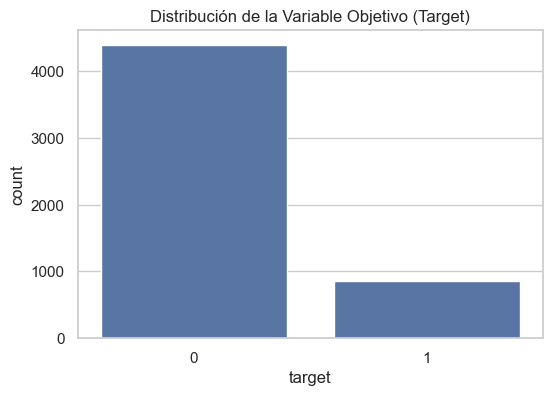

target
0    83.726684
1    16.273316
Name: proportion, dtype: float64


In [6]:
# Distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df_cliente, x='target')
plt.title('Distribución de la Variable Objetivo (Target)')
plt.show()

print(df_cliente['target'].value_counts(normalize=True) * 100)




Como observamos, la variable objetivo está desbalanceada, lo cual era de esperarse según la descripción del caso (~10% de clase positiva).




### 3. Limpieza y Preprocesamiento: Datos Cliente




In [7]:
# Tratamiento de valores nulos
# Vemos si 'age_alicorp' u otras tienen nulos
print("Nulos en datos cliente:")
print(df_cliente.isnull().sum())

# Imputaremos 'age_alicorp' con la mediana ya que es una variable de edad/antigüedad
if df_cliente['age_alicorp'].isnull().sum() > 0:
    median_age = df_cliente['age_alicorp'].median()
    df_cliente['age_alicorp'].fillna(median_age, inplace=True)
    
# Si existen otros nulos en flags numéricos, asumiremos 0 (Falso)
for col in ['has_credit_line', 'has_perfect_customer', 'has_marketing_impulse']:
    if df_cliente[col].isnull().sum() > 0:
        df_cliente[col].fillna(0, inplace=True)




Nulos en datos cliente:
customer_id               0
territory_id              0
segment                   0
age_alicorp              75
has_credit_line           0
has_perfect_customer      0
has_marketing_impulse     0
target                    0
dtype: int64


### 4. Análisis Exploratorio: Datos Transaccionales




In [8]:
print(f"Dimensiones Datos Transaccionales: {df_transaccional.shape}")
df_transaccional.head()




Dimensiones Datos Transaccionales: (392442, 6)


,date,customer_id,product_id,category_product,amount,discount
0,44026,2805,10000,CAT1,509,42
1,44026,3734,10001,CAT8,94,0
2,44026,3734,10002,CAT8,306,12
3,44026,3734,10003,CAT8,811,35
4,44026,3734,10004,CAT8,530,32


In [9]:
# Información de transaccional
df_transaccional.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392442 entries, 0 to 392441
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   date              392442 non-null  int64 
 1   customer_id       392442 non-null  int64 
 2   product_id        392442 non-null  int64 
 3   category_product  392442 non-null  object
 4   amount            392442 non-null  int64 
 5   discount          392442 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 18.0+ MB


In [10]:
# Verificación de nulos
print("Nulos en datos transaccionales:")
print(df_transaccional.isnull().sum())




Nulos en datos transaccionales:
date                0
customer_id         0
product_id          0
category_product    0
amount              0
discount            0
dtype: int64


Notamos que `date` viene en formato numérico (Excel serial date) u otro formato. Intentaremos convertirlo, aunque no es estrictamente necesario si solo calculamos agregaciones, pero para Recency (Recencia) sí lo es.




In [11]:
# Convertir date numérico a datetime si está en formato Excel (origen 1899-12-30)
# En el archivo head() vimos: 44026. 44026 en excel es 12/07/2020.
try:
    df_transaccional['date'] = pd.to_datetime(df_transaccional['date'], origin='1899-12-30', unit='D')
except Exception as e:
    print(f"No se pudo convertir fecha numéricamente: {e}. Se intentará directo.")
    df_transaccional['date'] = pd.to_datetime(df_transaccional['date'])

print(f"Rango de fechas: {df_transaccional['date'].min()} a {df_transaccional['date'].max()}")




Rango de fechas: 2020-07-14 00:00:00 a 2020-12-12 00:00:00


### 5. Ingeniería de Características (RFM + otras)




In [12]:
# Generar variables por cliente
# Fecha máxima para cálculo de Recency
max_date = df_transaccional['date'].max()

# Agregaciones
rfm = df_transaccional.groupby('customer_id').agg({
    'date': lambda x: (max_date - x.max()).days,  # Recency
    'product_id': 'count',                        # Frequency (número de transacciones/productos)
    'category_product': 'nunique',                # Variedad de categorías
    'amount': ['sum', 'mean'],                    # Monetary total y Ticket promedio
    'discount': 'sum'                             # Total descuento
})

# Renombrar columnas
rfm.columns = ['recency', 'frequency', 'unique_categories', 'total_amount', 'avg_ticket', 'total_discount']
rfm.reset_index(inplace=True)

# Crear feature adicional: Porcentaje de descuento sobre la venta
rfm['discount_rate'] = np.where(rfm['total_amount'] > 0, rfm['total_discount'] / rfm['total_amount'], 0)

rfm.head()




,customer_id,recency,frequency,unique_categories,total_amount,avg_ticket,total_discount,discount_rate
0,1,2,317,9,153167,483.176656,8452,0.055182
1,2,3,4432,9,2245743,506.710966,121912,0.054286
2,3,15,559,7,285946,511.531306,15405,0.053874
3,4,28,503,7,258438,513.793241,13571,0.052512
4,5,14,98,6,45812,467.469388,2576,0.056230


### 6. Unión de Tablas (Merge) -> ABT




In [13]:
# Unir datos demográficos con transaccionales
# Usamos left join desde cliente para mantener a todos (incluso si no transaccionaron)
df_abt = pd.merge(df_cliente, rfm, on='customer_id', how='left')

# Llenar nulos para clientes que no tuvieron transacciones
cols_to_fill = ['recency', 'frequency', 'unique_categories', 'total_amount', 'avg_ticket', 'total_discount', 'discount_rate']
for col in cols_to_fill:
    if col == 'recency':
        # Para recency, si no compró, le ponemos un valor alto (peor recency)
        df_abt[col].fillna(999, inplace=True)
    else:
        df_abt[col].fillna(0, inplace=True)

print(f"Dimensiones ABT: {df_abt.shape}")




Dimensiones ABT: (5254, 15)


### 7. Tratamiento de Categóricas




In [14]:
# Convertiremos territory_id y segment a variables dummy (One-Hot Encoding)
df_abt = pd.get_dummies(df_abt, columns=['territory_id', 'segment'], drop_first=True)




In [15]:
# Vista final del ABT
df_abt.head()




,customer_id,age_alicorp,has_credit_line,has_perfect_customer,has_marketing_impulse,target,recency,frequency,unique_categories,total_amount,...,territory_id_T2,territory_id_T3,territory_id_T4,territory_id_T5,territory_id_T6,segment_S1,segment_S3,segment_S4,segment_S5,segment_S6
0,1,9.0,1,0,1,1,2,317,9,153167,...,False,False,False,False,False,False,True,False,False,False
1,2,0.0,0,1,1,0,3,4432,9,2245743,...,True,False,False,False,False,False,True,False,False,False
2,3,4.0,1,0,0,0,15,559,7,285946,...,False,False,False,False,False,False,True,False,False,False
3,4,2.0,0,1,0,0,28,503,7,258438,...,False,False,False,False,False,False,True,False,False,False
4,5,2.0,0,1,1,0,14,98,6,45812,...,False,False,False,False,False,False,True,False,False,False


### 8. Exportación del ABT




In [16]:
# Guardar como CSV
abt_path = os.path.join(PROCESSED_DIR, 'abt_cliente.csv')
df_abt.to_csv(abt_path, index=False)
print(f"Analytical Base Table guardado exitosamente en: {abt_path}")



Analytical Base Table guardado exitosamente en: ../data/processed\abt_cliente.csv
